In [2]:
# Installation des bibliothèques qui ne sont pas par défaut sur Colab
!pip install networkx pandas matplotlib python-louvain cdlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import networkx as nx

# 1. Téléchargement (si ce n'est pas déjà fait)
!curl -O https://snap.stanford.edu/data/email-Eu-core.txt.gz
!curl -O https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz

# 2. Chargement du réseau (On force les nœuds en string)
G = nx.read_edgelist("email-Eu-core.txt.gz", create_using=nx.Graph())

# 3. Chargement des attributs (On force les IDs en string pour correspondre au graphe)
labels = pd.read_csv("email-Eu-core-department-labels.txt.gz", sep=' ', header=None, names=['node', 'dept'])
labels['node'] = labels['node'].astype(str) # Force le type string
dept_dict = labels.set_index('node')['dept'].to_dict()

# 4. Attribution propre
nx.set_node_attributes(G, dept_dict, 'department')

# Vérification : Est-ce que le premier nœud a bien un département ?
premier_noeud = list(G.nodes())[0]
print(f"Vérification : Le nœud {premier_noeud} a pour département : {G.nodes[premier_noeud].get('department', 'ERREUR: Pas de département')}")
print(f"✅ Réseau prêt : {G.number_of_nodes()} nœuds.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 79754  100 79754    0     0   118k      0 --:--:-- --:--:-- --:--:--  118k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2663  100  2663    0     0   6967      0 --:--:-- --:--:-- --:--:--  6971
Vérification : Le nœud 0 a pour département : 1
✅ Réseau prêt : 1005 nœuds.


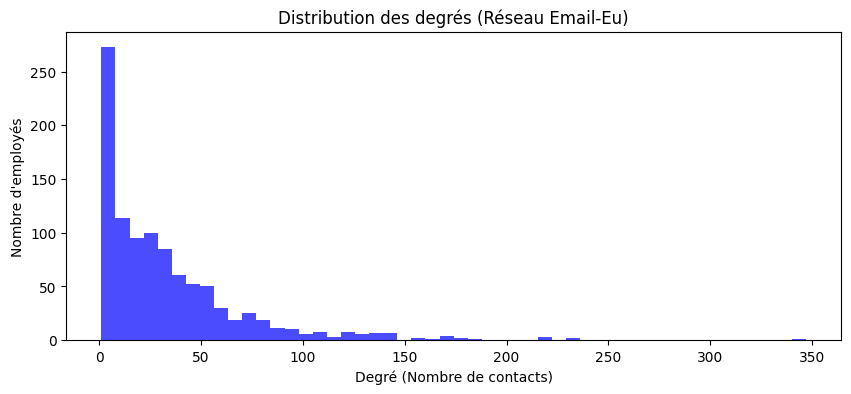

Densité du réseau : 0.0331
Coefficient de clustering moyen : 0.3994
Nombre de composants : 20

Top 5 des employés les plus centraux (ID, Score) :
ID: 160, Centralité: 0.3456
ID: 121, Centralité: 0.2331
ID: 82, Centralité: 0.2321
ID: 107, Centralité: 0.2201
ID: 86, Centralité: 0.2171


In [7]:
# 1. Distribution des degrés
degrees = [d for n, d in G.degree()]
plt.figure(figsize=(10, 4))
plt.hist(degrees, bins=50, color='blue', alpha=0.7)
plt.title("Distribution des degrés (Réseau Email-Eu)")
plt.xlabel("Degré (Nombre de contacts)")
plt.ylabel("Nombre d'employés")
plt.show()

# 2. Densité et Clustering
print(f"Densité du réseau : {nx.density(G):.4f}")
print(f"Coefficient de clustering moyen : {nx.average_clustering(G):.4f}")

# 3. Composants connectés
print(f"Nombre de composants : {nx.number_connected_components(G)}")

# 4. Centralité (Top 5)
cent = nx.degree_centrality(G)
top_5 = sorted(cent.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 des employés les plus centraux (ID, Score) :")
for node, val in top_5:
    print(f"ID: {node}, Centralité: {val:.4f}")

In [8]:
# On travaille sur le plus gros composant pour éviter les erreurs de réseaux déconnectés
largest_cc = max(nx.connected_components(G), key=len)
subgraph = G.subgraph(largest_cc)

print(f"Diamètre du réseau (plus grand composant) : {nx.diameter(subgraph)}")
print(f"Rayon du réseau : {nx.radius(subgraph)}")

Diamètre du réseau (plus grand composant) : 7
Rayon du réseau : 4


In [9]:
from networkx.algorithms import community

# 1. Détection des communautés
comm_louvain = community.louvain_communities(G)

# 2. Analyse sémantique de la plus grande communauté
# On trie les communautés par taille pour prendre la plus intéressante
sorted_comm = sorted(comm_louvain, key=len, reverse=True)
c1 = list(sorted_comm[0]) # La plus grande communauté

print(f"La plus grande communauté contient {len(c1)} membres.")

# 3. Récupération des départements réels des membres de cette communauté
# On utilise .get() pour éviter l'erreur KeyError
depts_reels = [G.nodes[n].get('department', 'Inconnu') for n in c1]

# 4. Statistique sur cette communauté : Quel est le département majoritaire ?
df_stats = pd.Series(depts_reels).value_counts()
print("\nTop 5 des départements présents dans cette communauté :")
print(df_stats.head(5))

# Calcul de la modularité
mod = community.modularity(G, comm_louvain)
print(f"\nModularité globale de Louvain : {mod:.4f}")

La plus grande communauté contient 265 membres.

Top 5 des départements présents dans cette communauté :
15    49
9     29
8     19
36    19
23    17
Name: count, dtype: int64

Modularité globale de Louvain : 0.4321


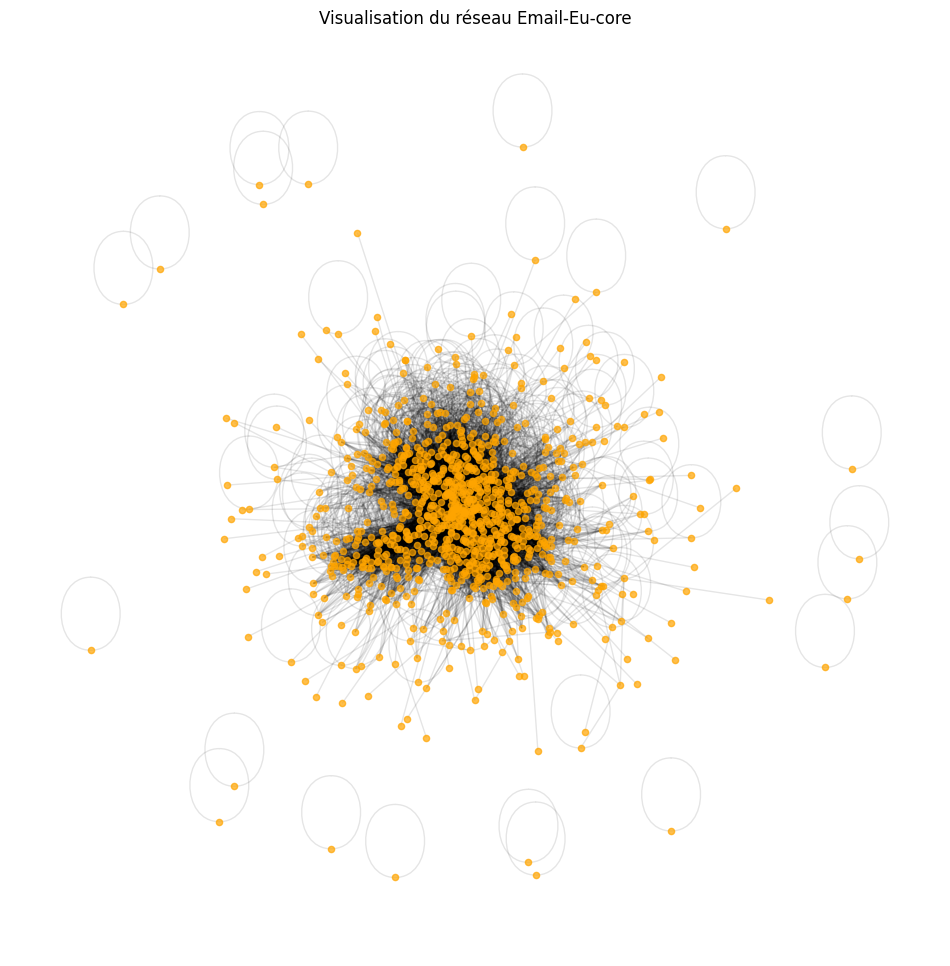

In [10]:
import matplotlib.pyplot as plt

# On prend un sous-échantillon ou on dessine simplement
plt.figure(figsize=(12, 12))
# On utilise spring_layout pour organiser les nœuds
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Dessiner les nœuds
nx.draw_networkx_nodes(G, pos, node_size=20, node_color='orange', alpha=0.7)
# Dessiner les liens
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title("Visualisation du réseau Email-Eu-core")
plt.axis('off')
plt.show()

In [11]:
import pandas as pd

# Préparation des données de comparaison
data_comp = {
    "Algorithme": ["Louvain", "Label Propagation", "Greedy Modularity"],
    "Nombre de Communautés": [len(comm_louvain), len(comm_lp), len(comm_greedy)],
    "Modularité": [
        community.modularity(G, comm_louvain),
        community.modularity(G, comm_lp),
        community.modularity(G, comm_greedy)
    ]
}

df_comparaison = pd.DataFrame(data_comp)
print("\n--- Tableau Comparatif des Algorithmes ---")
print(df_comparaison)


--- Tableau Comparatif des Algorithmes ---
          Algorithme  Nombre de Communautés  Modularité
0            Louvain                     27    0.432145
1  Label Propagation                     38    0.089003
2  Greedy Modularity                     44    0.366585


In [12]:
# Exporter le réseau avec ses attributs pour que le prof puisse l'ouvrir
nx.write_gexf(G, "email_eu_network.gexf")
print("\nFichier 'email_eu_network.gexf' exporté ! Vous pouvez le mettre sur votre GitHub.")


Fichier 'email_eu_network.gexf' exporté ! Vous pouvez le mettre sur votre GitHub.


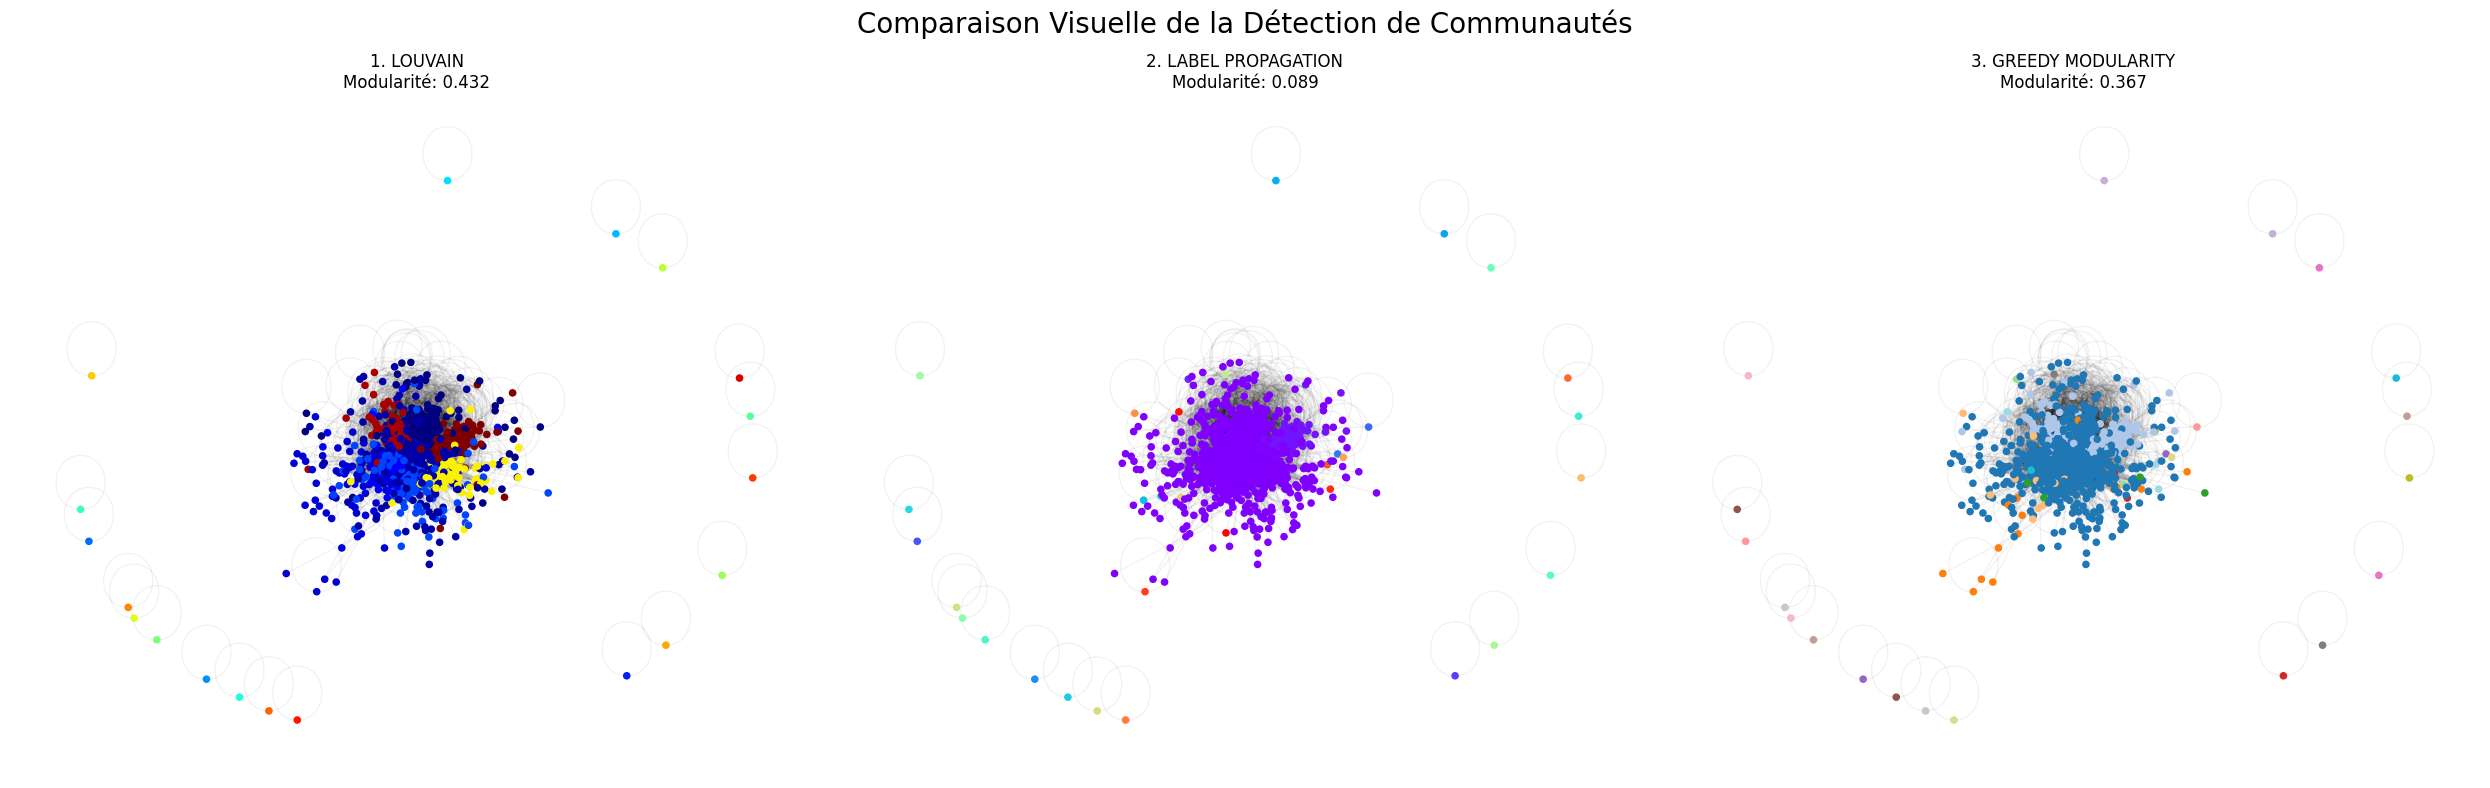

In [14]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import community

# On fixe la position pour que la forme du réseau soit identique sur les 3 graphes
pos = nx.spring_layout(G, k=0.15, seed=42)

# Création de la figure avec 3 zones (1 ligne, 3 colonnes)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 8))

# --- 1. LOUVAIN ---
colors_louvain = [next(i for i, c in enumerate(comm_louvain) if n in c) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=colors_louvain, cmap=plt.cm.jet, ax=ax1)
nx.draw_networkx_edges(G, pos, alpha=0.05, ax=ax1)
ax1.set_title(f"1. LOUVAIN\nModularité: {community.modularity(G, comm_louvain):.3f}")
ax1.axis('off')

# --- 2. LABEL PROPAGATION ---
colors_lp = [next(i for i, c in enumerate(comm_lp) if n in c) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=colors_lp, cmap=plt.cm.rainbow, ax=ax2)
nx.draw_networkx_edges(G, pos, alpha=0.05, ax=ax2)
ax2.set_title(f"2. LABEL PROPAGATION\nModularité: {community.modularity(G, comm_lp):.3f}")
ax2.axis('off')

# --- 3. GREEDY MODULARITY ---
colors_greedy = [next(i for i, c in enumerate(comm_greedy) if n in c) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=colors_greedy, cmap=plt.cm.tab20, ax=ax3)
nx.draw_networkx_edges(G, pos, alpha=0.05, ax=ax3)
ax3.set_title(f"3. GREEDY MODULARITY\nModularité: {community.modularity(G, comm_greedy):.3f}")
ax3.axis('off')

plt.suptitle("Comparaison Visuelle de la Détection de Communautés", fontsize=20)
plt.tight_layout()
plt.show()